# Optimization based on Santa Rosa Fire

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo

from scipy.optimize import differential_evolution

from src.fire_spreading_model import Parameters, FireSpreadingAdvanced
from src.data_preprocessing import SentinelClient
from src.helper_functions import calculate_rect_dimensions, collect_weather_data
from test.optimization import objective_function

/Users/hanno/PycharmProjects/Adv_Modelling_and_Simulation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Gathering Trainings Data

Width: 27.697km, Height: 17.255km, Area: 477.903sq km


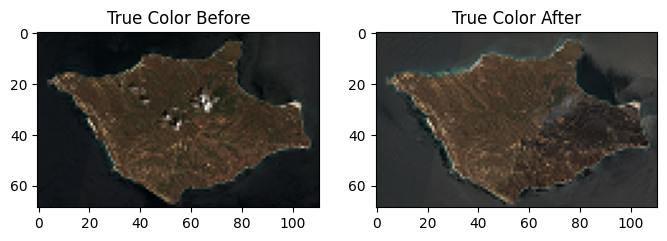

In [2]:
# time range for the satellite images
start_date = ("2026-04-20", "2026-04-24")  # actual start date: 2026-05-15 4:19 pm
end_date = ("2026-05-18", "2026-05-21")    # actual "end" date: 2026-05-19

# coordinate ranges for the satellite images
lat_range = (33.890, 34.045)
lon_range = (-120.260, -119.960)

width_km, height_km = calculate_rect_dimensions(lat_range, lon_range)
px_dimemnsion_km = 0.250
width_px = round(width_km / px_dimemnsion_km)
height_px = round(height_km / px_dimemnsion_km)

# origin of the fire
start_coord = (33.90969, -120.09063)
start_px = (round((start_coord[0] - lat_range[0]) / (lat_range[1] - lat_range[0]) * height_px),
            round((start_coord[1] - lon_range[0]) / (lon_range[1] - lon_range[0]) * width_px))

sc = SentinelClient()
photo_true_colour_before, _ = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                        np.max(lon_range), np.max(lat_range),
                                        start_date[0], start_date[1], width_px, height_px)

photo_true_colour_after, time_end = sc.get_photo(np.min(lon_range), np.min(lat_range),
                                       np.max(lon_range), np.max(lat_range),
                                       end_date[0], end_date[1], width_px, height_px)

print(f"Width: {width_km:.3f}km, Height: {height_km:.3f}km, Area: {width_km*height_km:.3f}sq km")

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(photo_true_colour_before)
ax[0].set_title("True Color Before")
ax[1].imshow(photo_true_colour_after)
ax[1].set_title("True Color After")
plt.show()

In [3]:
# set manual start time
time_start = datetime.fromisoformat("2026-05-15T16:00")
time_start = time_start.replace(tzinfo=ZoneInfo("America/Los_Angeles"))
time_start = time_start.astimezone(timezone.utc)

# use the end time from image and round it to nearest hour
time_end = datetime.fromisoformat(time_end)
time_end = (time_end + timedelta(minutes=30)).replace(minute=0, second=0, microsecond=0)

# calculate passed hours
delta_t = int((time_end - time_start).total_seconds() // 3600)

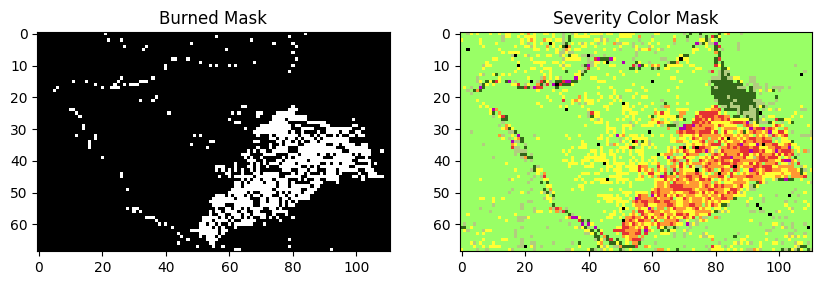

In [4]:
# Retrieve data
data_before = sc.get_data(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                          start_date[0], start_date[1], width_px, height_px)
data_after = sc.get_data(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                         end_date[0], end_date[1], width_px, height_px)

fuel_before, water_before, moisture_before, burnt_before = data_before
fuel_after_real_data, water_after_real_data, moisture_after_real_data, burnt_after_real_data = data_after

topo = sc.get_topo(np.min(lon_range), np.min(lat_range), np.max(lon_range), np.max(lat_range),
                   width_px, height_px)

#dNBR = (NBR_before - NBR_after)
dnbr = (burnt_before - burnt_after_real_data)

# Create the Target Burn Mask based on NBR and water levels
# white pixels indicate areas that were burned, while black pixels indicate unburned areas
target_mask = (dnbr > 0.1)

# severity mask based on dNBR
severity_color_mask, burned_mask = sc.get_severity_mask(dnbr)

# visualize the burned_mask and severity_color_mask
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(burned_mask, cmap='gray')
plt.title("Burned Mask")
plt.subplot(1,2,2)
plt.imshow(severity_color_mask)
plt.title("Severity Color Mask")
plt.show()

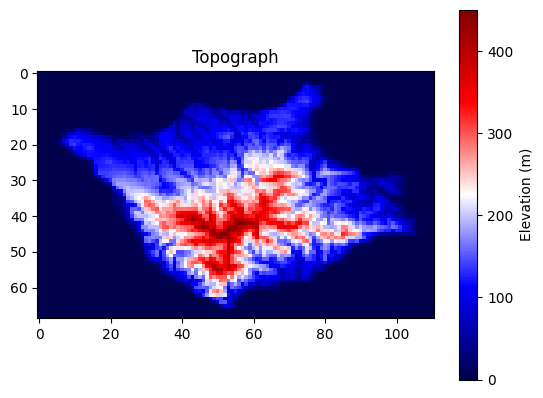

In [5]:
plt.imshow(topo, cmap="seismic")
plt.colorbar(label="Elevation (m)")
plt.title("Topograph")
plt.show()

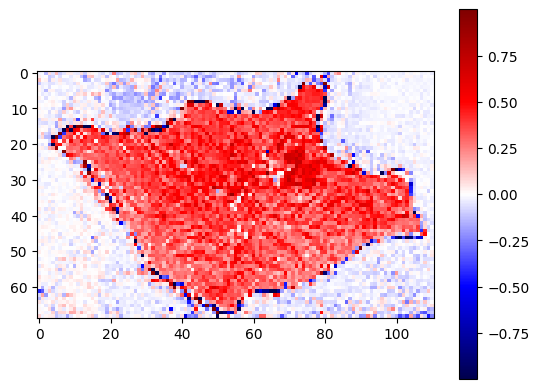

In [6]:
plt.imshow(fuel_before, cmap="seismic")
plt.colorbar()
plt.show()

In [7]:
# store masks for faster access
px = int(px_dimemnsion_km * 1000)
if False:
    np.savetxt(f"../data/santa_rosa/burned_px={px}m.csv", burned_mask, delimiter=";")
    np.savetxt(f"../data/santa_rosa/burnedbefore_px={px}m.csv", burnt_before, delimiter=";")
    np.savetxt(f"../data/santa_rosa/burnedafter_px={px}m.csv", burnt_after_real_data, delimiter=";")
    #np.savetxt(f"../data/santa_rosa/severity_px={px}m.csv", severity_color_mask, delimiter=";")
    np.savetxt(f"../data/santa_rosa/topo_px={px}m.csv", topo, delimiter=";")
    np.savetxt(f"../data/santa_rosa/moisturebefore_px={px}m.csv", moisture_before, delimiter=";")
    np.savetxt(f"../data/santa_rosa/moistureafter_px={px}m.csv", moisture_after_real_data, delimiter=";")
    np.savetxt(f"../data/santa_rosa/waterbefore_px={px}m.csv", water_before, delimiter=";")
    np.savetxt(f"../data/santa_rosa/waterafter_px={px}m.csv", water_after_real_data, delimiter=";")
    np.savetxt(f"../data/santa_rosa/fuelbefore_px={px}m.csv", fuel_before, delimiter=";")
    np.savetxt(f"../data/santa_rosa/fuelafter_px={px}m.csv", fuel_after_real_data, delimiter=";")
    np.savetxt(f"../data/santa_rosa/dnbr_px={px}m.csv", dnbr, delimiter=";")

### Weather Data

In [8]:
weather_data = collect_weather_data(np.average(lat_range), np.average(lon_range), time_start, time_end)
weather_data

,Time,Wind Speed (kph),Wind Direction (°)
23,2026-05-15 23:00:00+00:00,28.6,302
24,2026-05-16 00:00:00+00:00,28.6,302
25,2026-05-16 01:00:00+00:00,29.6,302
26,2026-05-16 02:00:00+00:00,29.8,305
27,2026-05-16 03:00:00+00:00,29.5,306
...,...,...,...
134,2026-05-20 14:00:00+00:00,12.0,294
135,2026-05-20 15:00:00+00:00,11.0,293
136,2026-05-20 16:00:00+00:00,10.0,298
137,2026-05-20 17:00:00+00:00,8.6,285


In [9]:
wind_speed = weather_data["Wind Speed (kph)"].to_list()
wind_direction = weather_data["Wind Direction (°)"].to_list()

In [10]:
assert len(weather_data) == delta_t, "Something went wrong! Too much or not enough wind data."

## Test the model

In [11]:
start_px = (round(height_px - ((start_coord[0] - lat_range[0]) / (lat_range[1] - lat_range[0]) * height_px)),
            round((start_coord[1] - lon_range[0]) / (lon_range[1] - lon_range[0]) * width_px))

In [12]:
params_dict = {
    "n": height_px, "m": width_px, "mu_H": 0.5, "mu_O": 0.5, "dF": 0.5, "dO": 0.5, "dW": 0.5, "ignition_temp": 0.3,
    "ignition_oxy": 0.76, "ignition_fuel": 0.3, "extinction_fuel": 0.15, "extinction_oxy": 0.05,
    "wind": None, "wind_velocity": wind_speed, "wind_direction": wind_direction, "start_cells": [start_px],
    "random_F": False, "fuel_mask": fuel_before, "water_mask": water_before, "moisture_mask": moisture_before,
    "topo_mask": topo, "k_slope": 0.1, "resolution": px, "wind_strength_factor": 0, "timesteps": delta_t,
}

parameter = Parameters(**params_dict)
sim = FireSpreadingAdvanced(parameter, precompute_mu=True)
sim.run_simulation(timesteps=delta_t, visualization=False)

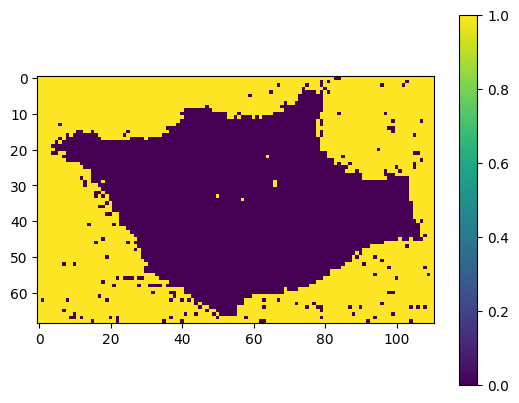

In [13]:
water = np.where(water_before >= 0, 1, 0)
plt.imshow(water)
plt.colorbar();

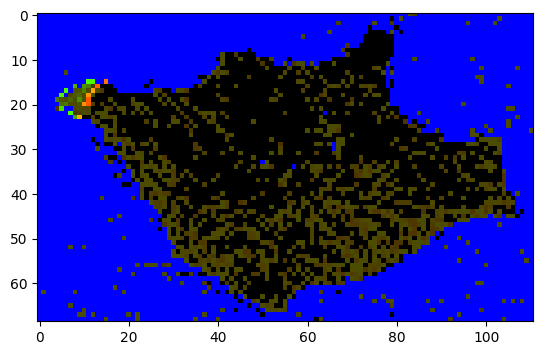

In [14]:
plt.imshow(sim._make_rgb());

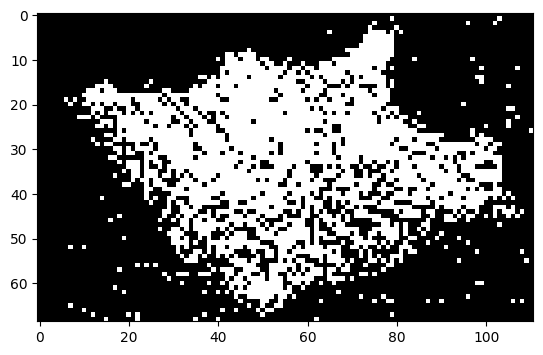

In [15]:
plt.imshow(sim.calculate_simulation_burned_mask(), cmap='gray');

differential_evolution step 1: f(x)= 0.49783549783549785
differential_evolution step 2: f(x)= 0.4913428241631397
differential_evolution step 3: f(x)= 0.4913428241631397
differential_evolution step 4: f(x)= 0.4913428241631397
differential_evolution step 5: f(x)= 0.4902965946539729
differential_evolution step 6: f(x)= 0.4902965946539729
differential_evolution step 7: f(x)= 0.4879078694817658
differential_evolution step 8: f(x)= 0.4879078694817658
differential_evolution step 9: f(x)= 0.48494329292139227
differential_evolution step 10: f(x)= 0.48448598130841125
differential_evolution step 11: f(x)= 0.48448598130841125
differential_evolution step 12: f(x)= 0.48193244304791827
differential_evolution step 13: f(x)= 0.48193244304791827
differential_evolution step 14: f(x)= 0.48193244304791827
differential_evolution step 15: f(x)= 0.4780047132757266
differential_evolution step 16: f(x)= 0.4780047132757266
differential_evolution step 17: f(x)= 0.4780047132757266
differential_evolution step 18: f

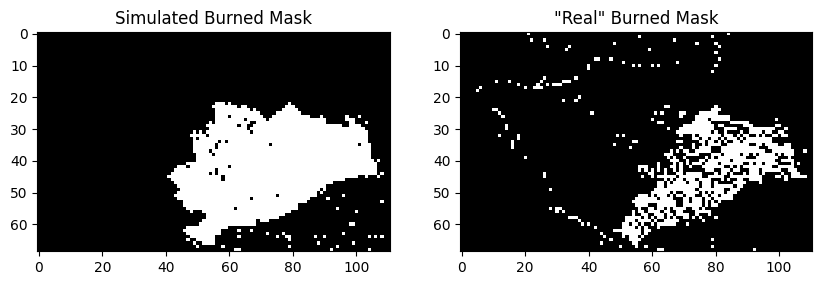

In [16]:
# define which parameters to optimize
params_opt = {
    "mu_H": (0.01, 1),
    "mu_O": (0.01, 1),
    "dF": (0.01, 1),
    "dO": (0.01, 1),
    "dW": (0.01, 1),
    "ignition_temp": (0.1, 0.9),
    "ignition_fuel": (0.01, 0.9),
    "extinction_fuel": (0.0, 0.9),
    "wind_strength_factor": (0.0, 10.0),
    "k_slope": (0.0, 10.0),
}
params_names = list(params_opt.keys())
bounds = list(params_opt.values())

params_static = params_dict.copy()  # so we can rerun this cell
for name in params_names:
    params_static.pop(name)

tracker = {"best_loss": float("inf"), "best_mask": None}
timesteps = params_static["timesteps"]
optimization = differential_evolution(
    objective_function,
    bounds=bounds,
    args=(target_mask, params_static, timesteps, tracker, params_names),
    strategy="best1bin",
    maxiter=1000,
    popsize=10,
    tol=1e-5,
    atol=0,
    disp=True,
    polish=False,
    workers=-1,
    updating="deferred",
)

print(f"\nBest Loss: {optimization.fun:.4f}")
for i in range(len(params_opt)):
    print(f"\t{list(params_opt.keys())[i]} = {optimization.x[i]:.2f}")
    params_dict[list(params_opt.keys())[i]] = optimization.x[i]

sim_opt = FireSpreadingAdvanced(Parameters(**params_dict), precompute_mu=True)
sim_opt.run_simulation(timesteps=delta_t, visualization=True, gif_name="sim_opt")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(sim_opt.calculate_simulation_burned_mask(), cmap='gray')
plt.title("Simulated Burned Mask")
plt.subplot(1,2,2)
plt.imshow(burned_mask, cmap='gray')
plt.title('"Real" Burned Mask')
plt.show()